# EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss

This notebook trains an EfficientNet-B0 model combining:
- **Entropy filtering**: Removes high-entropy samples for cleaner training
- **Ordinal loss**: Leverages the ordinal nature of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
- **Focal loss**: Focuses on hard examples and handles class imbalance

The combination addresses multiple challenges:
1. Ordinal structure ensures predictions respect grade ordering
2. Focal loss down-weights easy examples and focuses on hard misclassifications
3. Entropy filtering removes noisy/ambiguous samples

In [14]:
from torch import optim
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch
import random
import numpy as np
import torch.nn as nn
import torch.nn.functional as F
import albumentations as Albu
import pandas as pd
from torch.utils.data import DataLoader
from torch.utils.data.sampler import RandomSampler
from warmup_scheduler import GradualWarmupScheduler
from sklearn.metrics import accuracy_score, cohen_kappa_score, f1_score, recall_score, precision_score
from tqdm import tqdm
import os
from utils.dataset import PandasDataset
from utils.models import EfficientNetApi

## Configuration

In [15]:
# Training parameters
seed = 42
batch_size = 3
num_workers = 4
output_classes = 5  # For ordinal encoding: ISUP 0-5 → 5 thresholds
init_lr = 3e-4
warmup_factor = 2
warmup_epochs = 1
n_epochs = 50
dropout_rate = 0.6
patience = 7

# Focal loss parameters
focal_alpha = 0.25  # Weighting factor for focal loss
focal_gamma = 2.0   # Focusing parameter (higher = more focus on hard examples)

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Set seeds
torch.manual_seed(seed)
random.seed(seed)
np.random.seed(seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(seed)

# Paths
ROOT_DIR = '../../..'
data_dir = '../../../..'
images_dir = os.path.join(data_dir, 'tiles')

# Output paths
os.makedirs('../logs', exist_ok=True)
os.makedirs('../models', exist_ok=True)
model_path = 'models/b0-entropy-ordinal-focal-2.pth'
log_path = 'logs/b0-entropy-ordinal-focal-2.txt'

Using device: cuda


## Combined Ordinal + Focal Loss

This loss function combines:
1. **Ordinal encoding**: Converts ISUP grades to binary thresholds [1,1,...,1,0,0,...,0]
2. **Focal loss modulation**: Applies (1-p_t)^gamma weighting to focus on hard examples

Formula: `FL(p_t) = -alpha * (1 - p_t)^gamma * BCE(logits, ordinal_targets)`

In [16]:
class OrdinalFocalLoss(nn.Module):
    """
    Combined Ordinal + Focal Loss for ordered categories with class imbalance.
    
    Combines ordinal regression (respecting order) with focal loss (handling
    class imbalance and focusing on hard examples).
    
    For each sample with grade k, we create k binary labels:
    - ISUP 0: [0, 0, 0, 0, 0]
    - ISUP 1: [1, 0, 0, 0, 0]
    - ISUP 2: [1, 1, 0, 0, 0]
    - ISUP 3: [1, 1, 1, 0, 0]
    - ISUP 4: [1, 1, 1, 1, 0]
    - ISUP 5: [1, 1, 1, 1, 1]
    
    Then apply focal loss weighting:
    FL(p_t) = -alpha * (1 - p_t)^gamma * log(p_t)
    """
    def __init__(self, gamma=2.0, reduction='mean'):
        super(OrdinalFocalLoss, self).__init__()
        # Register alpha as a buffer so it moves with the model to GPU/CPU
        self.register_buffer('alpha', torch.tensor([0.25, 0.35, 0.50, 0.70, 0.90]))
        self.gamma = gamma
        self.reduction = reduction
    
    def forward(self, logits, targets):
        """
        Args:
            logits: (batch_size, num_classes) - raw outputs from model
            targets: (batch_size, num_classes) - ordinal encoded targets
        """
        # Apply sigmoid to get probabilities
        probs = torch.sigmoid(logits)
        
        # Calculate binary cross entropy (without reduction)
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        
        # Calculate p_t: probability of correct class
        # For target=1, p_t=p; for target=0, p_t=1-p
        p_t = probs * targets + (1 - probs) * (1 - targets)
        
        # Calculate focal weight: (1 - p_t)^gamma
        # This down-weights easy examples (high p_t) and focuses on hard examples (low p_t)
        focal_weight = (1 - p_t) ** self.gamma
        
        # Apply focal loss formula
        focal_loss = self.alpha * focal_weight * bce_loss
        
        if self.reduction == 'mean':
            return focal_loss.mean()
        elif self.reduction == 'sum':
            return focal_loss.sum()
        else:
            return focal_loss

def encode_ordinal_labels(labels, num_classes=5):
    """
    Convert categorical labels to ordinal encoding.
    
    Args:
        labels: Tensor or array of ISUP grades (0-5)
        num_classes: Number of thresholds (5 for ISUP 0-5)
    
    Returns:
        Ordinal encoded labels: (batch_size, num_classes)
    """
    if isinstance(labels, torch.Tensor):
        labels = labels.cpu().numpy()
    
    batch_size = len(labels)
    ordinal = torch.zeros((batch_size, num_classes), dtype=torch.float32)
    
    for i, label in enumerate(labels):
        label = int(label)
        if label > 0:
            ordinal[i, :label] = 1
    
    return ordinal

def decode_ordinal_predictions(logits):
    """
    Convert ordinal predictions back to class labels.
    
    Args:
        logits: (batch_size, num_classes) - raw model outputs
    
    Returns:
        Predicted ISUP grades (0-5)
    """
    probs = torch.sigmoid(logits)
    predictions = (probs > 0.5).sum(dim=1)
    return predictions

# Initialize loss function
loss_function = OrdinalFocalLoss(gamma=focal_gamma)
# Move loss function to device
loss_function = loss_function.to(device)
print(f"Ordinal + Focal Loss initialized and moved to {device}")
print(f"  Alpha weights per threshold: [0.25, 0.35, 0.50, 0.70, 0.90]")
print(f"  Gamma: {focal_gamma}")

Ordinal + Focal Loss initialized and moved to cuda
  Alpha weights per threshold: [0.25, 0.35, 0.50, 0.70, 0.90]
  Gamma: 2.0


## Load Data with Entropy Filtering

In [17]:
# Load original training data
df_train_ = pd.read_csv(f"{ROOT_DIR}/data/train_5fold.csv")
print(f"Original records: {len(df_train_)}")

# Load entropy filtered samples
df_entropy = pd.read_csv(f"{ROOT_DIR}/data/entropy.csv")
print(f"High-entropy samples to remove: {len(df_entropy)}")

df_entropy_sorted = df_entropy.sort_values(by='difficulty_score', ascending=False).reset_index(drop=True)

n_remove = int(len(df_entropy) * 0.2)

df_entropy_top = df_entropy_sorted.head(n_remove)
# Filter out high-entropy samples
df_train_ = df_train_[~df_train_['image_id'].isin(df_entropy_top['image_id'])].reset_index(drop=True)
print(f"Filtered records: {len(df_train_)}")

# Clean column names
df_train_.columns = df_train_.columns.str.strip()

# Split by fold (fold 3 for validation)
train_indexes = np.where(df_train_['fold'] != 3)[0]
valid_indexes = np.where(df_train_['fold'] == 3)[0]

df_train = df_train_.loc[train_indexes].reset_index(drop=True)
df_val = df_train_.loc[valid_indexes].reset_index(drop=True)

# Load test data
df_test = pd.read_csv(f"{ROOT_DIR}/data/test.csv")

def remove_nonexistent_images(df, images_dir):
    """
    Remove rows from df where the image does not exist in images_dir.
    """
    image_ids = df['image_id'].apply(lambda x: os.path.join(images_dir, f"{x}.png"))
    existent_images = [os.path.isfile(path) for path in image_ids]
    df = df[existent_images]
    return df

df_train = remove_nonexistent_images(df_train, images_dir)
df_val = remove_nonexistent_images(df_val, images_dir)
df_test = remove_nonexistent_images(df_test, images_dir)

print(f"\nTrain: {len(df_train)} samples")
print(f"Validation: {len(df_val)} samples")
print(f"Test: {len(df_test)} samples")

# Check class distribution
print(f"\nTrain class distribution:")
print(df_train['isup_grade'].value_counts().sort_index())

Original records: 9024
High-entropy samples to remove: 903
Filtered records: 8844

Train: 7073 samples
Validation: 1767 samples
Test: 1590 samples

Train class distribution:
isup_grade
0    1953
1    1802
2     899
3     826
4     832
5     761
Name: count, dtype: int64


## Data Augmentation

In [18]:
# Augmentation for training
train_transforms = Albu.Compose([
    Albu.Transpose(p=0.5),
    Albu.VerticalFlip(p=0.5),
    Albu.HorizontalFlip(p=0.5),
])

# No augmentation for validation/test
val_transforms = None

## Create Datasets and DataLoaders

In [19]:
# Create datasets
train_dataset = PandasDataset(images_dir, df_train, transforms=train_transforms, format="png")
valid_dataset = PandasDataset(images_dir, df_val, transforms=val_transforms, format="png")
test_dataset = PandasDataset(images_dir, df_test, transforms=val_transforms, format="png")

# Create dataloaders
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(train_dataset)
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    sampler=RandomSampler(valid_dataset)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    shuffle=False
)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(valid_loader)}")
print(f"Test batches: {len(test_loader)}")

Train batches: 2358
Validation batches: 589
Test batches: 530


## Model Setup

In [20]:
# Load pre-trained EfficientNet-B0
load_model = efficientnet_b0(weights=EfficientNet_B0_Weights.DEFAULT)
model = EfficientNetApi(model=load_model, output_dimensions=output_classes, dropout_rate=dropout_rate)
model = model.to(device)

print(f"Model loaded on {device}")
print(f"Output dimensions: {output_classes} (ordinal thresholds)")
print(f"Dropout rate: {dropout_rate}")

Model loaded on cuda
Output dimensions: 5 (ordinal thresholds)
Dropout rate: 0.6


## Optimizer and Scheduler

In [21]:
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=init_lr / warmup_factor)

# Scheduler with warmup
scheduler_cosine = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, n_epochs - warmup_epochs)
scheduler = GradualWarmupScheduler(
    optimizer,
    multiplier=warmup_factor,
    total_epoch=warmup_epochs,
    after_scheduler=scheduler_cosine
)

print("Optimizer and scheduler configured")

Optimizer and scheduler configured


## Training and Validation Functions

In [22]:
def training_step(model, dataloader, optimizer, device, loss_fn):
    """
    Perform one training epoch.
    """
    model.train()
    train_loss = []
    
    bar_progress = tqdm(dataloader, desc="Training")
    
    for batch_data, batch_targets, _ in bar_progress:
        batch_data = batch_data.to(device)
        batch_targets = batch_targets.to(device)  # Already in ordinal format from PandasDataset
        
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(batch_data)
        loss = loss_fn(logits, batch_targets)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        # Track loss
        loss_np = loss.detach().cpu().numpy()
        train_loss.append(loss_np)
        smooth_loss = sum(train_loss[-100:]) / min(len(train_loss), 100)
        
        bar_progress.set_postfix({'loss': f'{loss_np:.5f}', 'smooth_loss': f'{smooth_loss:.5f}'})
    
    return train_loss

def validation_step(model, dataloader, device, loss_fn):
    """
    Perform validation.
    """
    model.eval()
    
    validation_loss = []
    all_preds = []
    all_targets = []
    
    bar_progress = tqdm(dataloader, desc="Validation")
    
    with torch.no_grad():
        for batch_data, batch_targets, _ in bar_progress:
            batch_data = batch_data.to(device)
            batch_targets_ordinal = batch_targets.to(device)  # Already ordinal
            
            # Forward pass
            logits = model(batch_data)
            loss = loss_fn(logits, batch_targets_ordinal)
            
            # Decode predictions (sum of thresholds > 0.5)
            predictions = decode_ordinal_predictions(logits)
            
            # Convert ordinal targets back to class labels for metrics
            targets_class = batch_targets.sum(dim=1).long()
            
            all_preds.append(predictions.cpu())
            all_targets.append(targets_class)
            validation_loss.append(loss.cpu().numpy())
    
    # Concatenate all predictions and targets
    all_preds = torch.cat(all_preds).numpy()
    all_targets = torch.cat(all_targets).numpy()
    
    # Calculate metrics
    accuracy = accuracy_score(all_targets, all_preds)
    kappa = cohen_kappa_score(all_targets, all_preds, weights='quadratic')
    f1 = f1_score(all_targets, all_preds, average='macro', zero_division=0)
    recall = recall_score(all_targets, all_preds, average='macro', zero_division=0)
    precision = precision_score(all_targets, all_preds, average='macro', zero_division=0)
    
    return {
        'val_loss': np.mean(validation_loss),
        'val_acc': accuracy,
        'val_kappa': kappa,
        'val_f1': f1,
        'val_recall': recall,
        'val_precision': precision
    }

## Training Loop

In [23]:
best_kappa = 0.0
best_epoch = 0
epochs_without_improvement = 0

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'val_acc': [],
    'val_kappa': [],
    'val_f1': [],
    'val_recall': [],
    'val_precision': []
}

print("\nStarting training with Ordinal + Focal Loss...\n")
print("="*80)

for epoch in range(1, n_epochs + 1):
    print(f"\nEpoch {epoch}/{n_epochs}")
    print("-" * 80)
    
    # Train
    train_loss = training_step(model, train_loader, optimizer, device, loss_function)
    
    # Validate
    metrics = validation_step(model, valid_loader, device, loss_function)
    
    # Update scheduler
    scheduler.step()
    current_lr = optimizer.param_groups[0]['lr']
    
    # Save history
    history['train_loss'].append(np.mean(train_loss))
    history['val_loss'].append(metrics['val_loss'])
    history['val_acc'].append(metrics['val_acc'])
    history['val_kappa'].append(metrics['val_kappa'])
    history['val_f1'].append(metrics['val_f1'])
    history['val_recall'].append(metrics['val_recall'])
    history['val_precision'].append(metrics['val_precision'])
    
    # Print metrics
    print(f"\nResults:")
    print(f"  Train Loss: {history['train_loss'][-1]:.5f}")
    print(f"  Val Loss: {metrics['val_loss']:.5f}")
    print(f"  Val Accuracy: {metrics['val_acc']*100:.2f}%")
    print(f"  Val Kappa: {metrics['val_kappa']:.4f}")
    print(f"  Val F1: {metrics['val_f1']:.4f}")
    print(f"  Learning Rate: {current_lr:.7f}")
    
    # Log to file
    log_line = f"epoch: {epoch} | lr: {current_lr:.7f} | train_loss: {history['train_loss'][-1]:.5f} | val_loss: {metrics['val_loss']:.5f} | val_acc: {metrics['val_acc']:.4f} | val_kappa: {metrics['val_kappa']:.4f}\n"
    with open(log_path, 'a') as f:
        f.write(log_line)
    
    # Save best model
    if metrics['val_kappa'] > best_kappa:
        best_kappa = metrics['val_kappa']
        best_epoch = epoch
        epochs_without_improvement = 0
        torch.save(model.state_dict(), model_path)
        print(f"\n  Best model saved! Kappa: {best_kappa:.4f}")
    else:
        epochs_without_improvement += 1
        print(f"\n  No improvement for {epochs_without_improvement} epoch(s)")
    
    # Early stopping
    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch}")
        print(f"Best epoch: {best_epoch} with Kappa: {best_kappa:.4f}")
        break

print("\n" + "="*80)
print("Training completed!")
print(f"Best validation Kappa: {best_kappa:.4f} at epoch {best_epoch}")
print("="*80)


Starting training with Ordinal + Focal Loss...


Epoch 1/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [02:46<00:00,  3.55it/s]



Results:
  Train Loss: 0.05451
  Val Loss: 0.03833
  Val Accuracy: 56.65%
  Val Kappa: 0.8022
  Val F1: 0.5319
  Learning Rate: 0.0003000

  Best model saved! Kappa: 0.8022

Epoch 2/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [02:38<00:00,  3.72it/s]
/home/woshington/Projects/Doutorado/repo/.venv/lib/python3.12/site-packages/torch/optim/lr_scheduler.py:1087: UserWarning: To get the last learning rate computed by the scheduler, please use `get_last_lr()`.
  _warn_get_lr_called_within_step(self)



Results:
  Train Loss: 0.04715
  Val Loss: 0.04342
  Val Accuracy: 56.14%
  Val Kappa: 0.7373
  Val F1: 0.4772
  Learning Rate: 0.0003003

  No improvement for 1 epoch(s)

Epoch 3/50
--------------------------------------------------------------------------------


...


Results:
  Train Loss: 0.01558
  Val Loss: 0.04671
  Val Accuracy: 66.04%
  Val Kappa: 0.8508
  Val F1: 0.6198
  Learning Rate: 0.0000894

  No improvement for 5 epoch(s)

Epoch 34/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:31<00:00,  6.46it/s]



Results:
  Train Loss: 0.01468
  Val Loss: 0.04158
  Val Accuracy: 67.46%
  Val Kappa: 0.8545
  Val F1: 0.6256
  Learning Rate: 0.0000807

  No improvement for 6 epoch(s)

Epoch 35/50
--------------------------------------------------------------------------------


Validation: 100%|██████████| 589/589 [01:31<00:00,  6.46it/s]



Results:
  Train Loss: 0.01365
  Val Loss: 0.05130
  Val Accuracy: 66.78%
  Val Kappa: 0.8506
  Val F1: 0.6056
  Learning Rate: 0.0000723

  No improvement for 7 epoch(s)

Early stopping at epoch 35
Best epoch: 28 with Kappa: 0.8622

Training completed!
Best validation Kappa: 0.8622 at epoch 28


## Plot Training History

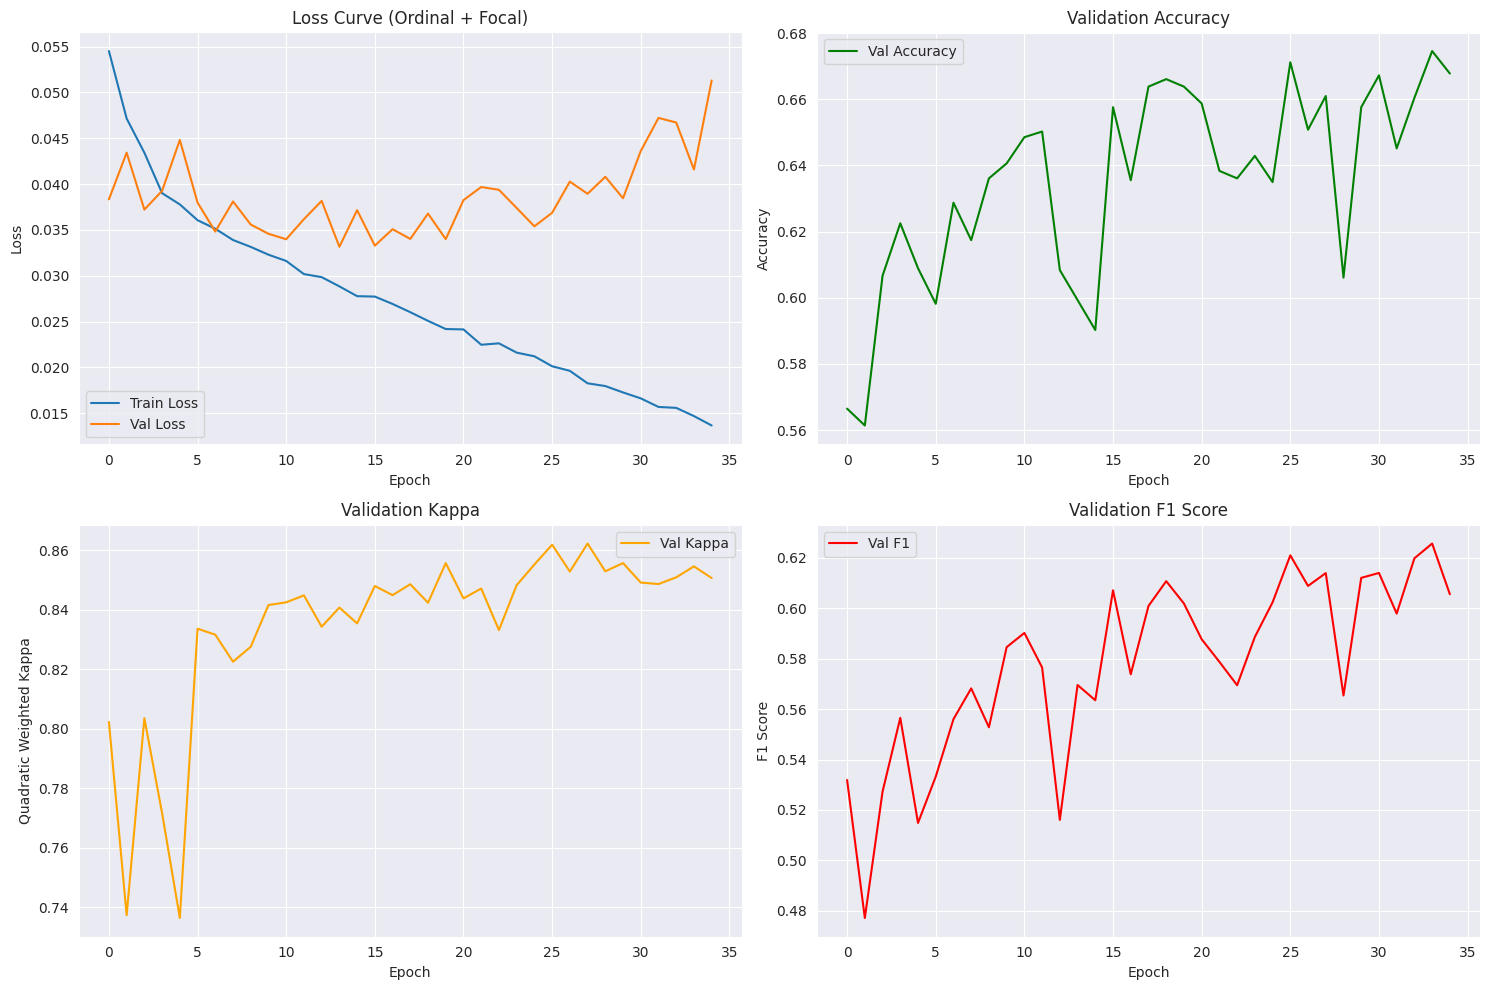

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Loss Curve (Ordinal + Focal)')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['val_acc'], label='Val Accuracy', color='green')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy')
axes[0, 1].set_title('Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# Kappa
axes[1, 0].plot(history['val_kappa'], label='Val Kappa', color='orange')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Quadratic Weighted Kappa')
axes[1, 0].set_title('Validation Kappa')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1', color='red')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-training.png', dpi=300, bbox_inches='tight')
plt.show()

## Evaluation on Test Set

Evaluating on test set...



Testing: 100%|██████████| 530/530 [01:22<00:00,  6.45it/s]



TEST SET RESULTS (Ordinal + Focal Loss)
Accuracy: 66.60%
Quadratic Weighted Kappa: 0.8575
Macro F1 Score: 0.6253

Classification Report:
              precision    recall  f1-score   support

      ISUP 0     0.8650    0.8710    0.8680       434
      ISUP 1     0.7131    0.6525    0.6815       400
      ISUP 2     0.4359    0.5100    0.4700       200
      ISUP 3     0.4802    0.4595    0.4696       185
      ISUP 4     0.5145    0.6631    0.5794       187
      ISUP 5     0.8074    0.5924    0.6834       184

    accuracy                         0.6660      1590
   macro avg     0.6360    0.6247    0.6253      1590
weighted avg     0.6802    0.6660    0.6694      1590


Confusion Matrix:
[[378  46   2   5   3   0]
 [ 38 261  85  12   4   0]
 [  2  42 102  39  14   1]
 [  5   6  33  85  47   9]
 [  9   4  10  24 124  16]
 [  5   7   2  12  49 109]]


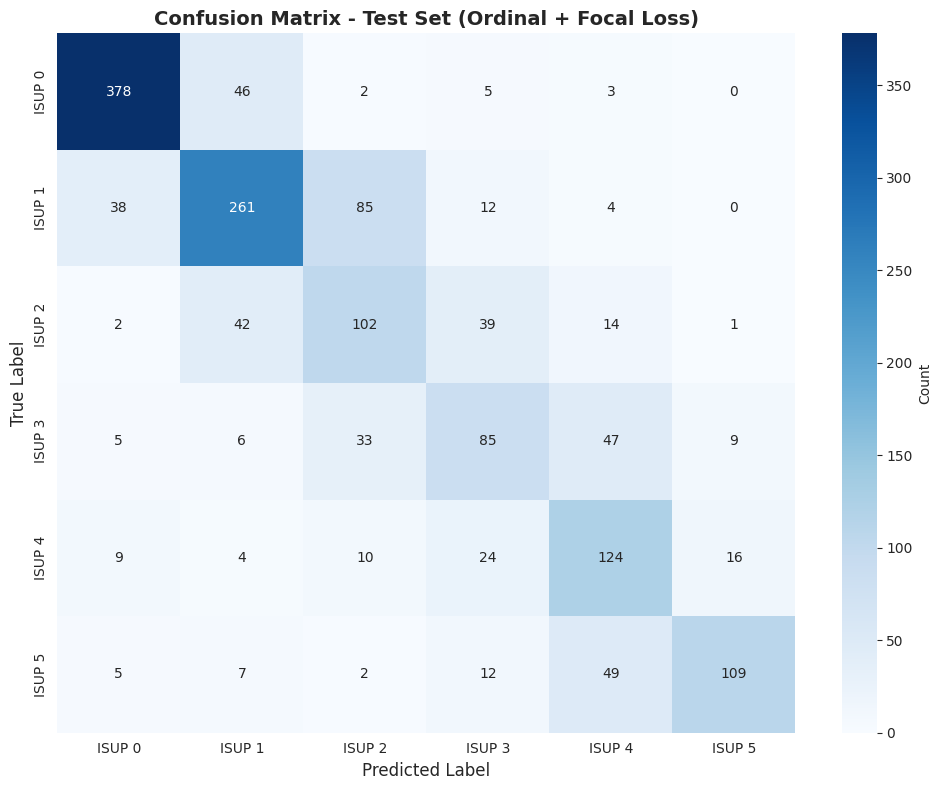


Test results saved to logs/b0-entropy-ordinal-focal-2-test-results.txt


In [25]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Load best model
model.load_state_dict(torch.load(model_path, weights_only=True))
model.eval()

# Evaluate on test set
test_preds = []
test_targets = []

print("Evaluating on test set...\n")

with torch.no_grad():
    for batch_data, batch_targets, _ in tqdm(test_loader, desc="Testing"):
        batch_data = batch_data.to(device)
        
        # Forward pass
        logits = model(batch_data)
        
        # Decode predictions
        predictions = decode_ordinal_predictions(logits)
        
        # Convert ordinal targets to class labels
        targets_class = batch_targets.sum(dim=1).long()
        
        test_preds.append(predictions.cpu())
        test_targets.append(targets_class)

# Concatenate results
test_preds = torch.cat(test_preds).numpy()
test_targets = torch.cat(test_targets).numpy()

# Calculate metrics
test_accuracy = accuracy_score(test_targets, test_preds)
test_kappa = cohen_kappa_score(test_targets, test_preds, weights='quadratic')
test_f1 = f1_score(test_targets, test_preds, average='macro', zero_division=0)

print("\n" + "="*80)
print("TEST SET RESULTS (Ordinal + Focal Loss)")
print("="*80)
print(f"Accuracy: {test_accuracy*100:.2f}%")
print(f"Quadratic Weighted Kappa: {test_kappa:.4f}")
print(f"Macro F1 Score: {test_f1:.4f}")
print("="*80)

# Classification report
print("\nClassification Report:")
print(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))

# Confusion matrix
cm = confusion_matrix(test_targets, test_preds)
print("\nConfusion Matrix:")
print(cm)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[f'ISUP {i}' for i in range(6)],
    yticklabels=[f'ISUP {i}' for i in range(6)],
    cbar_kws={'label': 'Count'}
)
plt.title('Confusion Matrix - Test Set (Ordinal + Focal Loss)', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-confusion-matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Save test results
with open('../logs/b0-entropy-ordinal-focal-2-test-results.txt', 'w') as f:
    f.write("EfficientNet-B0 with Entropy Filtering, Ordinal Loss, and Focal Loss\n")
    f.write("="*80 + "\n\n")
    f.write(f"Test Accuracy: {test_accuracy*100:.2f}%\n")
    f.write(f"Test Quadratic Weighted Kappa: {test_kappa:.4f}\n")
    f.write(f"Test Macro F1 Score: {test_f1:.4f}\n\n")
    f.write("Classification Report:\n")
    f.write(classification_report(test_targets, test_preds, target_names=[f'ISUP {i}' for i in range(6)], digits=4, zero_division=0))
    f.write("\nConfusion Matrix:\n")
    f.write(str(cm))

print("\nTest results saved to logs/b0-entropy-ordinal-focal-2-test-results.txt")

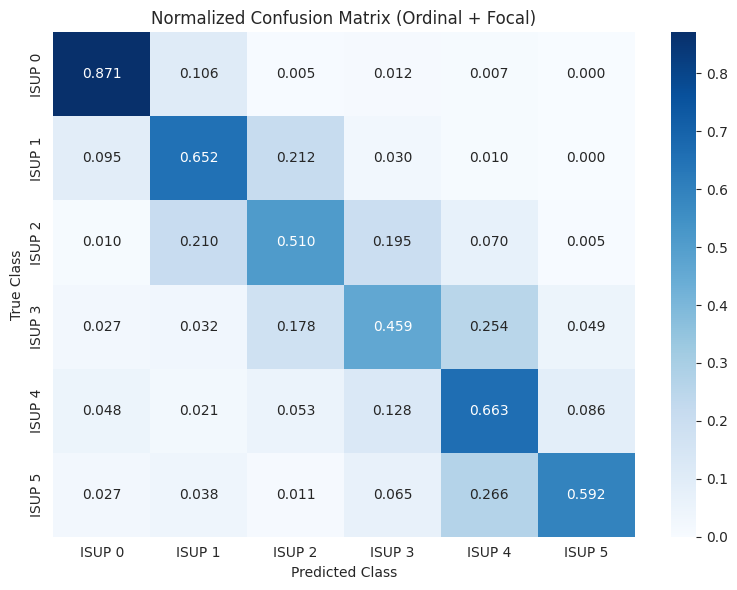

In [26]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Normalized confusion matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Labels for classes
classes = ['ISUP 0', 'ISUP 1', 'ISUP 2', 'ISUP 3', 'ISUP 4', 'ISUP 5']

# Plot
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm_normalized,
    annot=True,
    fmt=".3f",
    cmap="Blues",
    xticklabels=classes,
    yticklabels=classes
)
plt.title("Normalized Confusion Matrix (Ordinal + Focal)")
plt.ylabel("True Class")
plt.xlabel("Predicted Class")
plt.tight_layout()
plt.savefig('logs/b0-entropy-ordinal-focal-2-confusion-matrix-normalized.png', dpi=300, bbox_inches='tight')
plt.show()

## Summary

This notebook trained EfficientNet-B0 with a powerful combination of techniques:

1. **Entropy filtering** - Removed top 20% most difficult/ambiguous samples for cleaner training
2. **Ordinal loss** - Enforced the natural ordering of ISUP grades (0 < 1 < 2 < 3 < 4 < 5)
3. **Focal loss** - Down-weighted easy examples and focused learning on hard misclassifications

### How the combined loss works:

- **Ordinal encoding**: Each ISUP grade k is converted to k binary thresholds
  - ISUP 0: [0,0,0,0,0]
  - ISUP 3: [1,1,1,0,0] (grade > 0, > 1, > 2, but not > 3 or > 4)

- **Focal modulation**: Applied to each binary threshold prediction
  - Easy predictions (high confidence): Down-weighted by factor (1-p)^gamma
  - Hard predictions (low confidence): Retain full weight
  - Result: Model focuses on learning difficult threshold boundaries

### Expected benefits:

- Better handling of class imbalance (fewer high-grade samples)
- Reduced impact of easy negative examples
- Improved performance on minority classes (ISUP 4-5)
- Maintained ordinal consistency in predictions